In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('placement.csv')
df = df.head(8)    # take 8 samples for testing

In [18]:
df.rename(columns={'placement_exam_marks' : 'iq'}, inplace=True)
df

,cgpa,iq,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
5,7.30,23.0,1
6,6.69,11.0,0
7,7.12,39.0,1


### Calculate log-odds = loge(#1/#0)

In [19]:
ones = np.sum(df['placed'] == 1)
zeroes = 8-ones
print(ones, zeroes)
df['pred1(log-odds)'] = np.log(ones/zeroes)
df

6 2


,cgpa,iq,placed,pred1(log-odds)
0,7.19,26.0,1,1.098612
1,7.46,38.0,1,1.098612
2,7.54,40.0,1,1.098612
3,6.42,8.0,1,1.098612
4,7.23,17.0,0,1.098612
5,7.30,23.0,1,1.098612
6,6.69,11.0,0,1.098612
7,7.12,39.0,1,1.098612


### prediction of model1 in terms of probability

In [20]:
df['pred1(prob)'] = 1/(1+np.exp(-df['pred1(log-odds)']))
df

,cgpa,iq,placed,pred1(log-odds),pred1(prob)
0,7.19,26.0,1,1.098612,0.75
1,7.46,38.0,1,1.098612,0.75
2,7.54,40.0,1,1.098612,0.75
3,6.42,8.0,1,1.098612,0.75
4,7.23,17.0,0,1.098612,0.75
5,7.30,23.0,1,1.098612,0.75
6,6.69,11.0,0,1.098612,0.75
7,7.12,39.0,1,1.098612,0.75


### errors of model1 : residual (res1)

In [21]:
df['res1'] = df['placed'] - df['pred1(prob)']
df

,cgpa,iq,placed,pred1(log-odds),pred1(prob),res1
0,7.19,26.0,1,1.098612,0.75,0.25
1,7.46,38.0,1,1.098612,0.75,0.25
2,7.54,40.0,1,1.098612,0.75,0.25
3,6.42,8.0,1,1.098612,0.75,0.25
4,7.23,17.0,0,1.098612,0.75,-0.75
5,7.30,23.0,1,1.098612,0.75,0.25
6,6.69,11.0,0,1.098612,0.75,-0.75
7,7.12,39.0,1,1.098612,0.75,0.25


### model2 : Decision tree with input columns same as model1 and output as res1

In [24]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
# we are taking regressor here because the output column(res1) is in number format not categorical

In [27]:
dt2 = DecisionTreeRegressor(max_depth=2)
dt2.fit(df.iloc[:,0:1], df['res1'])

DecisionTreeRegressor(max_depth=2)

[Text(0.6, 0.8333333333333334, 'cgpa <= 7.265\nsquared_error = 0.188\nsamples = 8\nvalue = 0.0'),
 Text(0.4, 0.5, 'cgpa <= 7.21\nsquared_error = 0.24\nsamples = 5\nvalue = -0.15'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'squared_error = 0.188\nsamples = 4\nvalue = 0.0'),
 Text(0.6, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = -0.75'),
 Text(0.8, 0.5, 'squared_error = 0.0\nsamples = 3\nvalue = 0.25'),
 Text(0.7, 0.6666666666666667, '  False')]

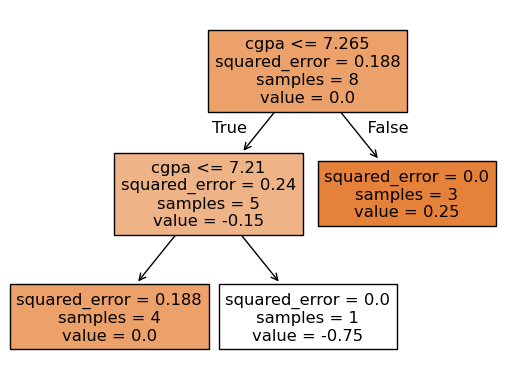

In [30]:
plot_tree(dt2, feature_names=df.columns, filled=True)

In [31]:
leaf_nodes = dt2.apply(df.iloc[:,0:1])
leaf_nodes

array([2, 4, 4, 2, 3, 4, 2, 2])

In [32]:
df['leaf_entry1'] = leaf_nodes
df

,cgpa,iq,placed,pred1(log-odds),pred1(prob),res1,leaf_entry1
0,7.19,26.0,1,1.098612,0.75,0.25,2
1,7.46,38.0,1,1.098612,0.75,0.25,4
2,7.54,40.0,1,1.098612,0.75,0.25,4
3,6.42,8.0,1,1.098612,0.75,0.25,2
4,7.23,17.0,0,1.098612,0.75,-0.75,3
5,7.30,23.0,1,1.098612,0.75,0.25,4
6,6.69,11.0,0,1.098612,0.75,-0.75,2
7,7.12,39.0,1,1.098612,0.75,0.25,2


In [35]:
df['pred2(log-odds)'] = (
    df.groupby('leaf_entry1')['res1'].transform('sum') /
    df.groupby('leaf_entry1').apply(
        lambda x: np.sum(x['pred1(prob)'] * (1 - x['pred1(prob)']))
    ).reindex(df['leaf_entry1']).values
)
df

/tmp/ipykernel_194/2876089146.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('leaf_entry1').apply(


,cgpa,iq,placed,pred1(log-odds),pred1(prob),res1,leaf_entry1,pred2(log-odds)
0,7.19,26.0,1,1.098612,0.75,0.25,2,0.000000
1,7.46,38.0,1,1.098612,0.75,0.25,4,1.333333
2,7.54,40.0,1,1.098612,0.75,0.25,4,1.333333
3,6.42,8.0,1,1.098612,0.75,0.25,2,0.000000
4,7.23,17.0,0,1.098612,0.75,-0.75,3,-4.000000
5,7.30,23.0,1,1.098612,0.75,0.25,4,1.333333
6,6.69,11.0,0,1.098612,0.75,-0.75,2,0.000000
7,7.12,39.0,1,1.098612,0.75,0.25,2,0.000000


In [36]:
df['pred2(prob)'] = 1/(1+np.exp(-df['pred2(log-odds)']))
df

,cgpa,iq,placed,pred1(log-odds),pred1(prob),res1,leaf_entry1,pred2(log-odds),pred2(prob)
0,7.19,26.0,1,1.098612,0.75,0.25,2,0.000000,0.500000
1,7.46,38.0,1,1.098612,0.75,0.25,4,1.333333,0.791391
2,7.54,40.0,1,1.098612,0.75,0.25,4,1.333333,0.791391
3,6.42,8.0,1,1.098612,0.75,0.25,2,0.000000,0.500000
4,7.23,17.0,0,1.098612,0.75,-0.75,3,-4.000000,0.017986
5,7.30,23.0,1,1.098612,0.75,0.25,4,1.333333,0.791391
6,6.69,11.0,0,1.098612,0.75,-0.75,2,0.000000,0.500000
7,7.12,39.0,1,1.098612,0.75,0.25,2,0.000000,0.500000


In [37]:
df['res2'] = df['placed'] - (df['pred1(prob)'] + df['pred2(prob)'])
df

,cgpa,iq,placed,pred1(log-odds),pred1(prob),res1,leaf_entry1,pred2(log-odds),pred2(prob),res2
0,7.19,26.0,1,1.098612,0.75,0.25,2,0.000000,0.500000,-0.250000
1,7.46,38.0,1,1.098612,0.75,0.25,4,1.333333,0.791391,-0.541391
2,7.54,40.0,1,1.098612,0.75,0.25,4,1.333333,0.791391,-0.541391
3,6.42,8.0,1,1.098612,0.75,0.25,2,0.000000,0.500000,-0.250000
4,7.23,17.0,0,1.098612,0.75,-0.75,3,-4.000000,0.017986,-0.767986
5,7.30,23.0,1,1.098612,0.75,0.25,4,1.333333,0.791391,-0.541391
6,6.69,11.0,0,1.098612,0.75,-0.75,2,0.000000,0.500000,-1.250000
7,7.12,39.0,1,1.098612,0.75,0.25,2,0.000000,0.500000,-0.250000
